In [ ]:
!pip install xarray netCDF4
! pip install matplotlib seaborn

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
!{sys.executable} -m pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiofiles-25.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.10.11-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.7 kB)
  Using cached aiohttp_retry-2.8.3-py3-none-any.whl.metadata (8.9 kB)
  Using cached aioice-0.10.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached aiortc-1.14.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached aiosqlite-0.21.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached albucore-0.0.33-py3-none-any.whl.metadata (7.8 kB)
  Using cached albumentationsx-2.0.11-py3-none-any.whl.metadata (79 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached anywidget-0.9.18-py3-none-a

In [4]:
import xarray as xr
clean_ds = xr.open_dataset("clean_complex_network_dataset.nc")
print(clean_ds)

<xarray.Dataset> Size: 3GB
Dimensions:      (lon: 268, lat: 141, time: 2790)
Coordinates:
  * lon          (lon) float32 1kB -26.0 -25.75 -25.5 -25.25 ... 40.5 40.75 41.0
  * lat          (lat) float32 564B 35.8 36.05 36.3 36.55 ... 70.5 70.75 71.0
  * time         (time) datetime64[ns] 22kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    DC           (time, lat, lon) float32 422MB ...
    CC           (time, lat, lon) float32 422MB ...
    BC           (time, lat, lon) float32 422MB ...
    ID           (time, lat, lon) float32 422MB ...
    OD           (time, lat, lon) float32 422MB ...
    is_heatwave  (time, lat, lon) float32 422MB ...


## Build X and next-day target Y - choose COEFFICIENTS AND TARGET

In [ ]:
import xarray as xr

def choose_coefficients_and_target(ds, coeffs, target):
    return xr.concat([ds[coeff] for coeff in coeffs], dim="channel").assign_coords(channel=list(coeffs)), ds[target]

COEFFS = ["DC", "CC", "BC", "ID", "OD"]
TARGET = "is_heatwave"
TASK_TYPE = "binary"  # or "regression"

# X coefficients at time t
X, y = choose_coefficients_and_target(clean_ds, COEFFS, TARGET)

# target y at time t+1
y = y.shift(time=-1)

# drop last time step (because y(t+1) missing at end)
X = X.isel(time=slice(None, -1))
y = y.isel(time=slice(None, -1))

print("X:", X.dims, X.shape)   
print("y:", y.dims, y.shape)
print("channels:", [str(c) for c in X.channel.values])

X: ('channel', 'time', 'lat', 'lon') (5, 2789, 141, 268)
y: ('time', 'lat', 'lon') (2789, 141, 268)
channels: ['DC', 'CC', 'BC', 'ID', 'OD']


## Adjust to the Iberia region

In [6]:
# Iberia bounding box 
lon_min, lon_max = -10, 4
lat_min, lat_max = 36, 44

X_ib = X.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
y_ib = y.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

print("X_ib:", X_ib.shape, X_ib.dims)
print("y_ib:", y_ib.shape, y_ib.dims)

X_ib: (5, 2789, 32, 56) ('channel', 'time', 'lat', 'lon')
y_ib: (2789, 32, 56) ('time', 'lat', 'lon')


## Use the range 1990-2003

In [7]:
X_0103 = X_ib.sel(time=slice("1990-06-01", "2003-08-31"))
y_0103 = y_ib.sel(time=slice("1990-06-01", "2003-08-31"))

print("Time range:", str(X_0103.time.values[0]), "→", str(X_0103.time.values[-1]))

Time range: 1990-06-01T00:00:00.000000000 → 2003-08-31T00:00:00.000000000


## Yearly sequences

In [8]:
import numpy as np

def make_sequences_per_year(X, y, seq_len=14):
    """
    X: (channel, time, lat, lon)
    y: (time, lat, lon)
    Returns:
      X_seq: (N, seq_len, C, H, W)
      y_seq: (N, 1, H, W)
      y_dates: (N,) numpy datetime64 array = date of the target day
    """
    # time-first arrays
    Xt = X.transpose("time", "channel", "lat", "lon")
    yt = y.transpose("time", "lat", "lon")

    years = np.unique(Xt.time.dt.year.values)
    X_list, y_list, d_list = [], [], []

    for yr in years:
        Xy = Xt.sel(time=str(yr))
        yy = yt.sel(time=str(yr))

        T = Xy.sizes["time"]
        if T <= seq_len:
            continue

        Xv = Xy.values  # (T, C, H, W)
        yv = yy.values  # (T, H, W)
        times = Xy.time.values

        for i in range(T - seq_len):
            X_list.append(Xv[i:i+seq_len])
            y_list.append(yv[i+seq_len])         # predict next day after the window
            d_list.append(times[i+seq_len])      # store target day timestamp

    X_seq = np.stack(X_list).astype(np.float32)          # (N, L, C, H, W)
    y_seq = np.stack(y_list).astype(np.float32)[:, None] # (N, 1, H, W)
    y_dates = np.array(d_list)

    return X_seq, y_seq, y_dates

seq_len = 14
X_seq, y_seq, y_dates = make_sequences_per_year(X_0103, y_0103, seq_len=seq_len)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Target dates:", y_dates[0], "→", y_dates[-1])
print("y unique (sample):", np.unique(y_seq[:1]))

X_seq: (1030, 14, 5, 32, 56)
y_seq: (1030, 1, 32, 56)
Target dates: 1990-06-15T00:00:00.000000000 → 2003-08-31T00:00:00.000000000
y unique (sample): [0. 1.]


In [10]:
import numpy as np

y_dates_d = y_dates.astype("datetime64[D]")

train_mask = (y_dates_d >= np.datetime64("1990-06-01")) & (y_dates_d <= np.datetime64("2002-08-31"))
val_mask   = (y_dates_d >= np.datetime64("2003-06-01")) & (y_dates_d <= np.datetime64("2003-07-26"))
test_mask  = (y_dates_d >= np.datetime64("2003-07-27")) & (y_dates_d <= np.datetime64("2003-08-31"))

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val,   y_val   = X_seq[val_mask],   y_seq[val_mask]
X_test,  y_test  = X_seq[test_mask],  y_seq[test_mask]
test_dates = y_dates_d[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test dates:", test_dates[0], "→", test_dates[-1])

print("Heatwave fraction train/val/test:",
      float(y_train.mean()), float(y_val.mean()), float(y_test.mean()))

Train: (952, 14, 5, 32, 56) (952, 1, 32, 56)
Val:   (42, 14, 5, 32, 56) (42, 1, 32, 56)
Test:  (36, 14, 5, 32, 56) (36, 1, 32, 56)
Test dates: 2003-07-27 → 2003-08-31
Heatwave fraction train/val/test: 0.07550715655088425 0.12756431102752686 0.2352120578289032


#### Final check after split (to ensure no NaN or inf values)

In [11]:
print("Raw NaN in X_train:", np.isnan(X_train).any(), "Inf:", np.isinf(X_train).any())

Raw NaN in X_train: False Inf: False


Test tensor (47, 14, 5, 32, 56):
47 different target days
14 day input window 
5 channels 
Iberia grid 32x56

### Split - Train: 1990–2002, Val: 2003-06-01 → 2003-07-26, Test: 2003-07-27 → 2003-08-31

In [19]:
def normalize_per_channel(X_train, X_val, X_test, eps=1e-6):
    mean = X_train.mean(axis=(0,1,3,4), keepdims=True)
    std  = X_train.std(axis=(0,1,3,4), keepdims=True)
    return ((X_train - mean) / (std + eps),
            (X_val   - mean) / (std + eps),
            (X_test  - mean) / (std + eps),
            mean, std)

X_train_n, X_val_n, X_test_n, mean, std = normalize_per_channel(X_train, X_val, X_test)

## Class imbalance

In [20]:
import numpy as np

pos = float(y_train.sum())
neg = float(y_train.size - y_train.sum())

print("Positive pixels:", pos)
print("Negative pixels:", neg)
print("Positive ratio:", pos / (pos + neg))
print("Negative ratio:", neg / (pos + neg))

Positive pixels: 128814.0
Negative pixels: 1577170.0
Positive ratio: 0.07550715598739496
Negative ratio: 0.924492844012605


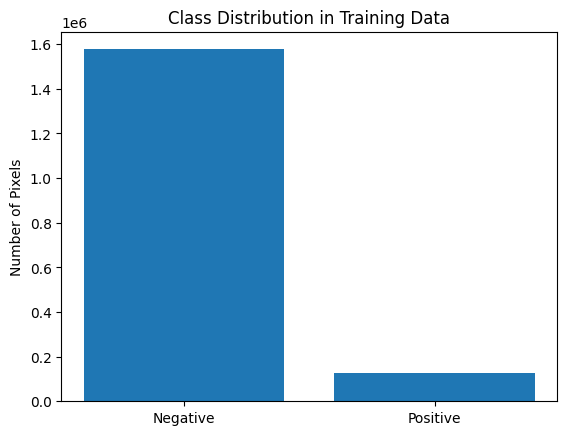

In [21]:
import matplotlib.pyplot as plt

pos = y_train.sum()
neg = y_train.size - pos

plt.bar(["Negative", "Positive"], [neg, pos])
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Pixels")
plt.show()

## ConvLSTM

In [58]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class NumpySeqDataset(Dataset):
    # wraps numpy arrays into a PyTorch Dataset for easy batching
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  # (N - samples, L - frames/time steps, C - number of channels per frame, H - height, W - width)
        self.y = torch.from_numpy(y).float()  # (N labels, 1, H, W) - target is heatwave next day (binary mask - Y/N)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

class ConvLSTMCell(nn.Module):
    # standard LSTM cell but with convolutional gates instead of linear (standard LSTM does fully connected gates, ConvLSTM does convolutional gates to preserve spatial structure)
    # we do it to keep the spatial relationships between neighboring cells 
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim,
                              kernel_size=kernel_size, padding=padding)
        # LSTM uses matrix multiplication to compute gates, we replace it with 2D convolution to preserve spatial structure, the hidden state remains a spatial feature map instead of collapsing space into a vector

    def forward(self, x, h, c):
        # x: (B, Cin, H, W), h/c: (B, Chid, H, W)
        combined = torch.cat([x, h], dim=1) # x and h are concatenated along the channel dimension to form the input to the convolutional gates 
        # x is the current input frame (with all channels), h is the previous hidden state (also a feature map), it carries information from previous time steps, by concatenating them we allow the gates to compute based on both current input and past hidden state
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i) # how much of new info to write into memory
        f = torch.sigmoid(f) # how much of old memory to keep
        o = torch.sigmoid(o) # how much of memory to expose as hidden state
        g = torch.tanh(g) # candidate new memory content
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, kernel_size=3):
        """
        TASK_TYPE:
            - 'binary'     -> returns raw logits for BCEWithLogitsLoss
            - 'regression' -> returns sigmoid-bounded output in [0,1]
        """
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.head = nn.Conv2d(hidden_dim, 1, kernel_size=1)

        if TASK_TYPE not in ["binary", "regression"]:
            raise ValueError("task_type must be 'binary' or 'regression'")

    def forward(self, x):
        # x: (B, L, C, H, W)
        B, L, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)

        for t in range(L):
            h, c = self.cell(x[:, t], h, c)

        out = self.head(h)  # (B, 1, H, W)

        if TASK_TYPE == "binary":
            # raw logits, because BCEWithLogitsLoss expects logits
            return out

        elif TASK_TYPE == "regression":
            # bounded output for targets like CC in [0,1]
            return torch.sigmoid(out)

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = NumpySeqDataset(X_train_n, y_train)
val_ds   = NumpySeqDataset(X_val_n, y_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

model = ConvLSTM(input_dim=len(COEFFS), hidden_dim=32, kernel_size=3).to(device)

# pos_weight = (#neg / #pos) over training pixels
pos = float(y_train.sum())
neg = float(y_train.size - y_train.sum())
pos_weight = torch.tensor([neg / (pos + 1e-6)], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
    return float(np.mean(losses))

for epoch in range(1, 11):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f}")

Epoch 01 | val_loss=1.0608
Epoch 02 | val_loss=1.0014
Epoch 03 | val_loss=0.9595
Epoch 04 | val_loss=0.9633
Epoch 05 | val_loss=0.9891
Epoch 06 | val_loss=0.9711
Epoch 07 | val_loss=0.9468
Epoch 08 | val_loss=0.9707
Epoch 09 | val_loss=0.9481
Epoch 10 | val_loss=0.9781


## get validation predictions

In [ ]:
val_ds = NumpySeqDataset(X_val_n, y_val)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

model.eval()

all_pred_val = []
all_true_val = []

with torch.no_grad():
    for Xb, yb in val_loader:
        Xb = Xb.to(device)

        logits = model(Xb)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_pred_val.append(probs)
        all_true_val.append(yb.numpy())

pred_val = np.concatenate(all_pred_val, axis=0)
true_val = np.concatenate(all_true_val, axis=0)

print(pred_val.shape, true_val.shape)

(42, 1, 32, 56) (42, 1, 32, 56)


## Choose the best threshold

In [40]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 50)

best_thr = 0
best_f1 = 0

for thr in thresholds:
    pred_bin = (pred_val >= thr).astype(np.uint8)
    f1 = f1_score(true_val.ravel(), pred_bin.ravel())
    
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print("Best threshold:", best_thr)
print("Best validation F1:", best_f1)

Best threshold: 0.7295918367346939
Best validation F1: 0.6026891898451532


In [ ]:
from sklearn.metrics import f1_score

test_ds = NumpySeqDataset(X_test_n, y_test)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model.eval()
all_pred = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_pred.append(probs)
        all_true.append(yb.numpy())

pred = np.concatenate(all_pred, axis=0)  # (N, 1, H, W)
true = np.concatenate(all_true, axis=0)

# threshold at best validation threshold
pred_bin = (pred >= best_thr).astype(np.uint8)
true_bin = (true >= best_thr).astype(np.uint8)

# pixel F1 (flatten all pixels)
f1 = f1_score(true_bin.ravel(), pred_bin.ravel())
print("Test pixel F1:", f1)

# IoU (Jaccard) over pixels
intersection = (pred_bin & true_bin).sum()
union = (pred_bin | true_bin).sum()
iou = (intersection / (union + 1e-6))
print("Test IoU:", float(iou))

Test pixel F1: 0.754174633524538
Test IoU: 0.6053614365066066


#### It is important to find the best threshold, since the dataset is very imbalanced, mostly it is background pixels, not heatwave ones. The threshold tuning just converts that ranking into a better binary mask. 

## Metrics


In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)
import numpy as np

# flatten once
y_true = true_bin.ravel()
y_pred = pred_bin.ravel()
y_prob = pred.ravel()

# --- core metrics ---
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

# IoU
intersection = (y_pred & y_true).sum()
union = (y_pred | y_true).sum()
iou = intersection / (union + 1e-6)

# PR-AUC
pr_auc = average_precision_score(y_true, y_prob)

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_prob)

# Brier score (probability quality)
brier = np.mean((y_prob - y_true) ** 2)

print(f"F1: {f1:.4f}")
print(f"IoU: {iou:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Brier: {brier:.4f}")

F1: 0.7542
IoU: 0.6054
PR-AUC: 0.7657
ROC-AUC: 0.8729
Precision: 0.7302
Recall: 0.7798
Specificity: 0.9114
Balanced Acc: 0.8456
Brier: 0.1880


# Pipeline - binary (is_heatwave) and non-binary (CC, ID, OD) target prediction

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)

def get_probs_and_true(model, loader, device, apply_sigmoid=True):
    """
    Returns:
        pred_prob: (N, 1, H, W)
        true:      (N, 1, H, W)
    """
    model.eval()
    all_pred = []
    all_true = []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            logits = model(Xb)

            if apply_sigmoid:
                probs = torch.sigmoid(logits).cpu().numpy()
            else:
                probs = logits.cpu().numpy()

            all_pred.append(probs)
            all_true.append(yb.numpy())

    pred_prob = np.concatenate(all_pred, axis=0)
    true = np.concatenate(all_true, axis=0)
    return pred_prob, true


def compute_binary_metrics(y_true_bin, y_pred_bin, y_prob):
    """
    Inputs are flattened 1D arrays.
    """
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    intersection = np.logical_and(y_true_bin, y_pred_bin).sum()
    union = np.logical_or(y_true_bin, y_pred_bin).sum()
    iou = intersection / (union + 1e-6)

    pr_auc = average_precision_score(y_true_bin, y_prob)

    # ROC-AUC can fail if only one class is present
    
    roc_auc = roc_auc_score(y_true_bin, y_prob)

    # tn = np.logical_and(y_true_bin == 0, y_pred_bin == 0).sum()      
    # fp = np.logical_and(y_true_bin == 0, y_pred_bin == 1).sum()
    # specificity = tn / (tn + fp + 1e-6)

    brier = np.mean((y_prob - y_true_bin) ** 2)

    return {
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "iou": float(iou),
        "pr_auc": float(pr_auc),
        "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        "brier": float(brier),
    }

def compute_non_binary_metrics(y_true_bin, y_prob):
    """
    For metrics that don't require a binary threshold (e.g. ROC-AUC, PR-AUC, Brier).
    """
    pr_auc = average_precision_score(y_true_bin, y_prob)
    roc_auc = roc_auc_score(y_true_bin, y_prob)
    brier = np.mean((y_prob - y_true_bin) ** 2)
    rmse = np.sqrt(np.mean((y_prob - y_true_bin) ** 2))
    r_squared = 1 - np.sum((y_true_bin - y_prob) ** 2) / np.sum((y_true_bin - np.mean(y_true_bin)) ** 2)
    mae = np.mean(np.abs(y_prob - y_true_bin))
    pearson_corr = np.corrcoef(y_true_bin, y_prob)[0, 1]

    return {
        "pr_auc": float(pr_auc),
        "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        "brier": float(brier),
        "rmse": float(rmse),
        "r_squared": float(r_squared),
        "mae": float(mae),
        "pearson_corr": float(pearson_corr),
    }

In [50]:
def find_best_threshold(y_true, y_prob, metric="f1", thresholds=None):
    """
    y_true: original target array, shape (N, 1, H, W) or similar
    y_prob: predicted probabilities, same shape
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    y_true_bin = (y_true >= 0.5).astype(np.uint8).ravel()
    y_prob_flat = y_prob.ravel()

    best_thr = None
    best_score = -np.inf
    best_metrics = None

    for thr in thresholds:
        y_pred_bin = (y_prob_flat >= thr).astype(np.uint8)
        metrics = compute_binary_metrics(y_true_bin, y_pred_bin, y_prob_flat)

        score = metrics[metric]
        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = metrics

    return best_thr, best_score, best_metrics

In [ ]:
def evaluate_experiment(
    model,
    val_loader,
    test_loader,
    device,
    experiment_name,
    input_features,
    target_name,
    threshold_metric="f1",
    apply_sigmoid=True,
    binary_metrics_only=True
    ):
    # --- validation ---
    val_prob, val_true = get_probs_and_true(model, val_loader, device, apply_sigmoid=apply_sigmoid)
    best_thr, best_val_score, val_metrics_at_best = find_best_threshold(
        val_true, val_prob, metric=threshold_metric
    )

    # --- test ---
    test_prob, test_true = get_probs_and_true(model, test_loader, device, apply_sigmoid=apply_sigmoid)

    y_true_bin = (test_true >= 0.5).astype(np.uint8).ravel()
    y_prob_flat = test_prob.ravel()
    y_pred_bin = (y_prob_flat >= best_thr).astype(np.uint8)

    if binary_metrics_only:
        test_metrics = compute_binary_metrics(y_true_bin, y_pred_bin, y_prob_flat)
        result = {
            "experiment": experiment_name,
            "inputs": ", ".join(input_features) if isinstance(input_features, (list, tuple)) else str(input_features),
            "target": target_name,
            "threshold_metric": threshold_metric,
            "best_val_threshold": float(best_thr),
            f"best_val_{threshold_metric}": float(best_val_score),

            # validation metrics at chosen threshold
            "val_f1": val_metrics_at_best["f1"],
            "val_iou": val_metrics_at_best["iou"],
            "val_precision": val_metrics_at_best["precision"],
            "val_recall": val_metrics_at_best["recall"],
            "val_pr_auc": val_metrics_at_best["pr_auc"],
            "val_roc_auc": val_metrics_at_best["roc_auc"],
            "val_brier": val_metrics_at_best["brier"],

            # test metrics
            "test_f1": test_metrics["f1"],
            "test_iou": test_metrics["iou"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_brier": test_metrics["brier"],
        }

    else:
        test_metrics = compute_non_binary_metrics(y_true_bin, y_prob_flat)
        result = {
            "experiment": experiment_name,
            "inputs": ", ".join(input_features) if isinstance(input_features, (list, tuple)) else str(input_features),
            "target": target_name,
            "threshold_metric": threshold_metric,
            "best_val_threshold": float(best_thr),
            f"best_val_{threshold_metric}": float(best_val_score),

            # validation metrics at chosen threshold
            "val_rmse"

            # non-binary metrics on test set
            "test_rmse": test_metrics["rmse"],
            "test_r_squared": test_metrics["r_squared"],
            "test_mae": test_metrics["mae"],
            "test_pearson_corr": test_metrics["pearson_corr"],
        }

        

    return result

In [55]:
import os

def append_result_to_csv(result_dict, csv_path="ablation_results.csv"):
    df_new = pd.DataFrame([result_dict])

    if os.path.exists(csv_path):
        df_old = pd.read_csv(csv_path)
        df_all = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(csv_path, index=False)
    return df_all

In [56]:
# example names
experiment_name = "all_coeffs_plus_hw_to_hw" # change experiment name for each run to keep track of different ablations
input_features = ["CC", "BC", "ID", "OD", "DC", "is_heatwave"]
target_name = "is_heatwave"

result = evaluate_experiment(
    model=model,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    experiment_name=experiment_name,
    input_features=input_features,
    target_name=target_name,
    threshold_metric="f1",   # or "iou"
    apply_sigmoid=True,       # for BCE/logit models
    binary_metrics_only=True # change this depending on the target prediction and model type (if not binary classification, set to False 
)

print(result)

df_all = append_result_to_csv(result, csv_path="ablation_results.csv")
print(df_all.tail())

{'experiment': 'all_coeffs_plus_hw_to_hw', 'inputs': 'CC, BC, ID, OD, DC, is_heatwave', 'target': 'is_heatwave', 'threshold_metric': 'f1', 'best_val_threshold': 0.72, 'best_val_f1': 0.6033508763459031, 'val_f1': 0.6033508763459031, 'val_iou': 0.431998893698956, 'val_precision': 0.5623762376237624, 'val_recall': 0.6507655452557025, 'val_pr_auc': 0.6539373513388128, 'val_roc_auc': 0.8714225378414178, 'val_balanced_accuracy': 0.7883604008202885, 'val_specificity': 0.9259552563707728, 'val_brier': 0.1906777322292328, 'test_f1': 0.7550813008130082, 'test_iou': 0.6065306122139525, 'test_precision': 0.7286992766948633, 'test_recall': 0.7834453670752604, 'test_pr_auc': 0.7657394143957046, 'test_roc_auc': 0.8728852323198585, 'test_balanced_accuracy': 0.8468688183627142, 'test_specificity': 0.910292269631718, 'test_brier': 0.18799690902233124}
                 experiment                           inputs       target  \
0  all_coeffs_plus_hw_to_hw  CC, BC, ID, OD, DC, is_heatwave  is_heatwave   


In [ ]:
df = pd.read_csv("ablation_results.csv")
df = df.sort_values(by="test_pr_auc", ascending=False)
print(df)

## Visualise the predictions 

### 27.07.2003


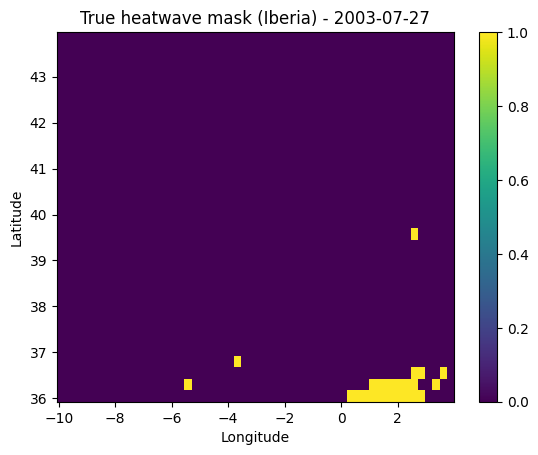

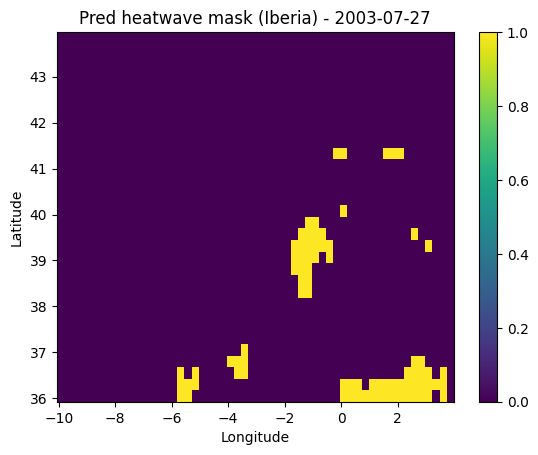

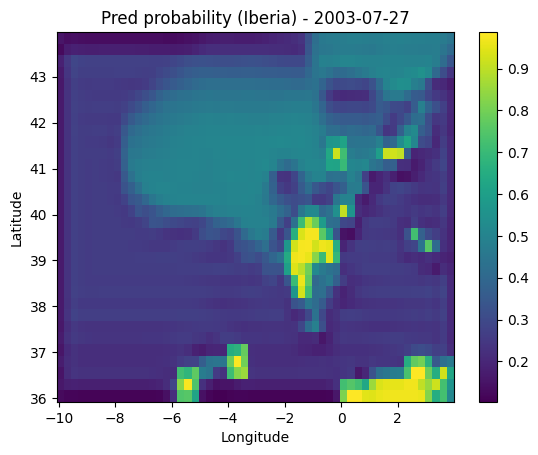

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-07-27")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= best_thr).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-07-27")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-07-27")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-07-27")

### 1.08.2003

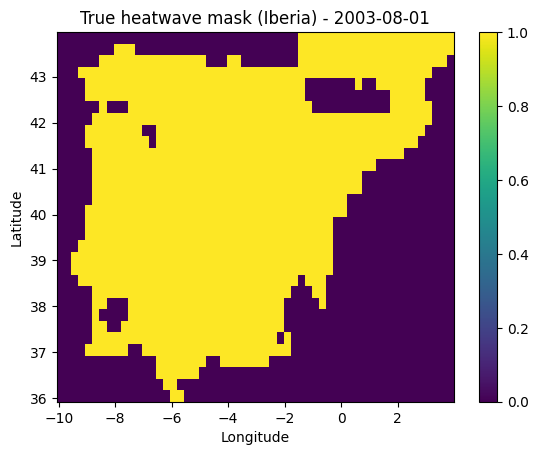

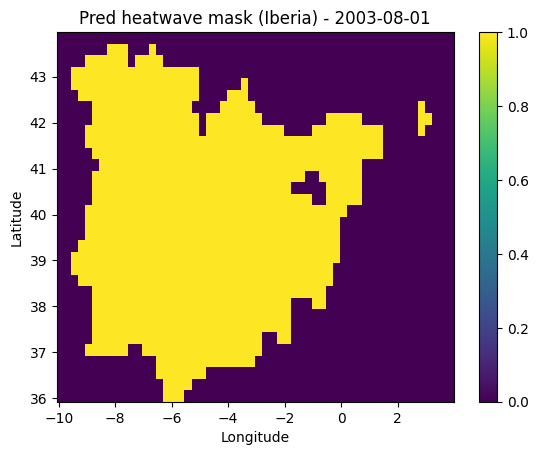

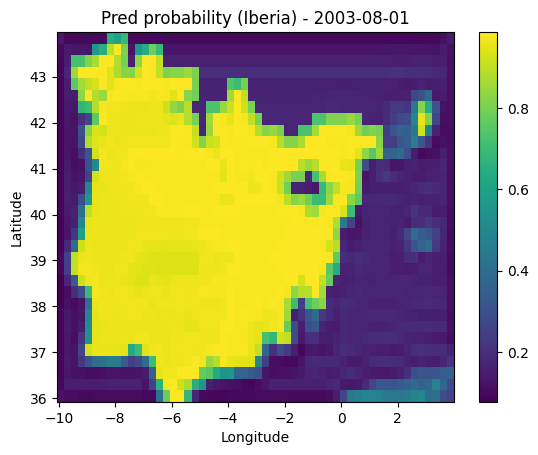

In [136]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-08-01")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= best_thr).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-08-01")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-08-01")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-08-01")

### 5.08.2003

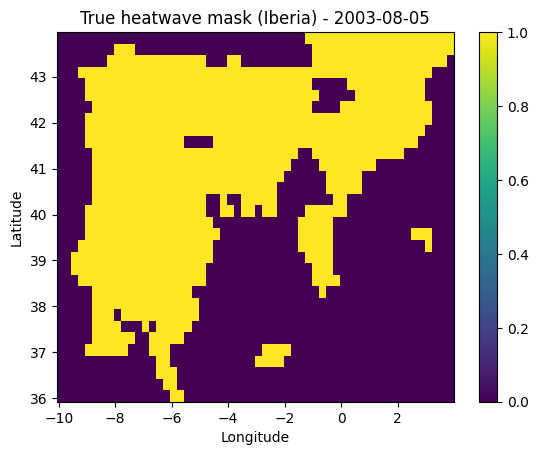

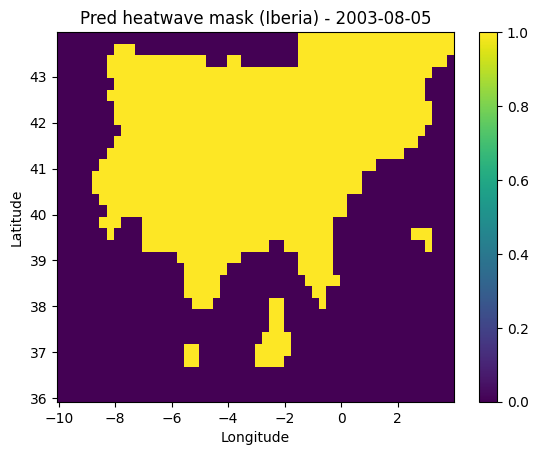

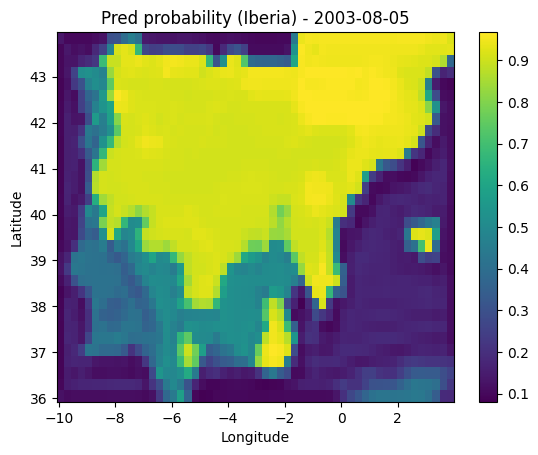

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-08-05")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= best_thr).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-08-05")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-08-05")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-08-05")

### 10.08.2003

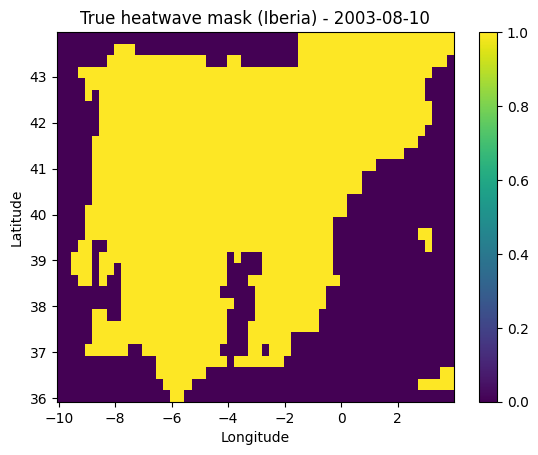

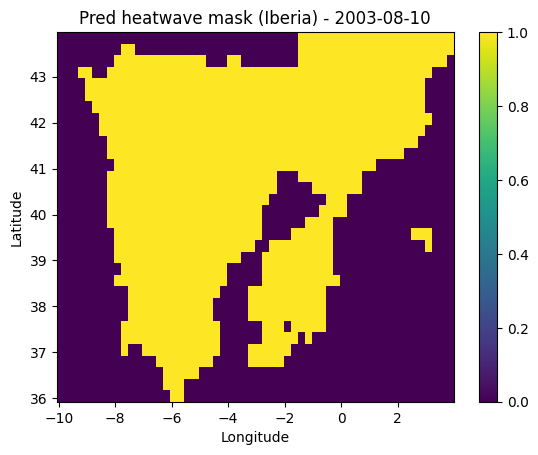

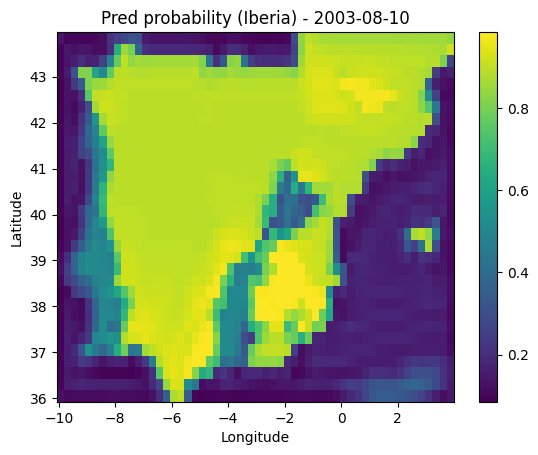

In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-08-10")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= best_thr).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-08-10")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-08-10")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-08-10")

### 15.08.2003

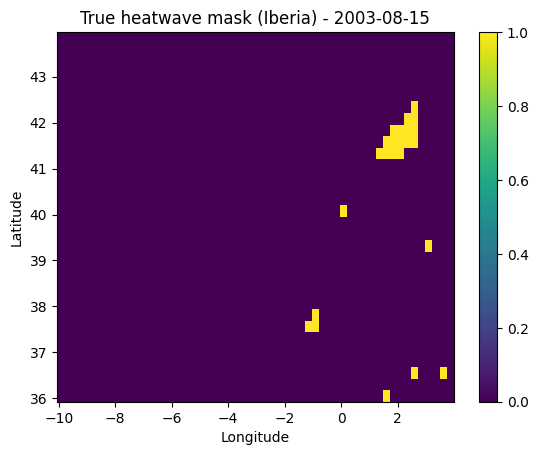

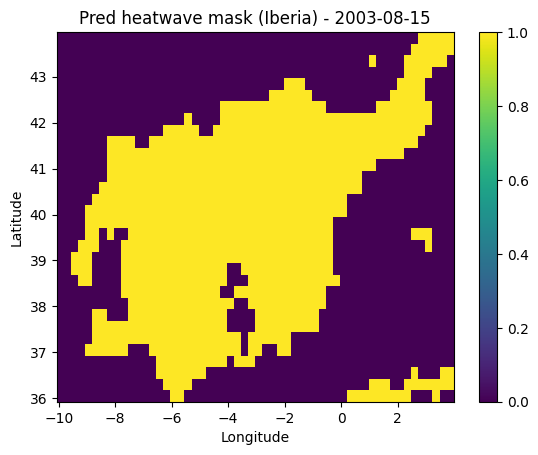

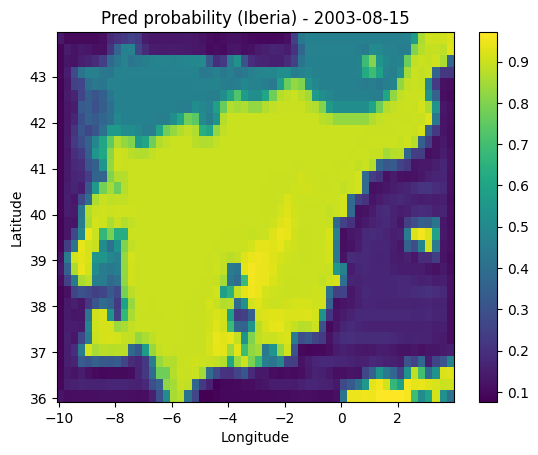

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-08-15")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= best_thr).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-08-15")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-08-15")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-08-15")

So given the past 14 days, the model predicts there is an (for example) 82% chance that tomorrow this location is in heatwave. IoU compares: 

Predicted region  ∩  True region / Predicted region  ∪  True region

## Heatwave trajectory visualisation

In [159]:
dates_to_plot = [
    np.datetime64("2003-07-27"),
    np.datetime64("2003-07-28"),
    np.datetime64("2003-07-29"),
    np.datetime64("2003-07-30"),
    np.datetime64("2003-07-31"),
    np.datetime64("2003-08-01"),
    np.datetime64("2003-08-02"),
    np.datetime64("2003-08-03"),
    np.datetime64("2003-08-04"),
    np.datetime64("2003-08-05"),

]

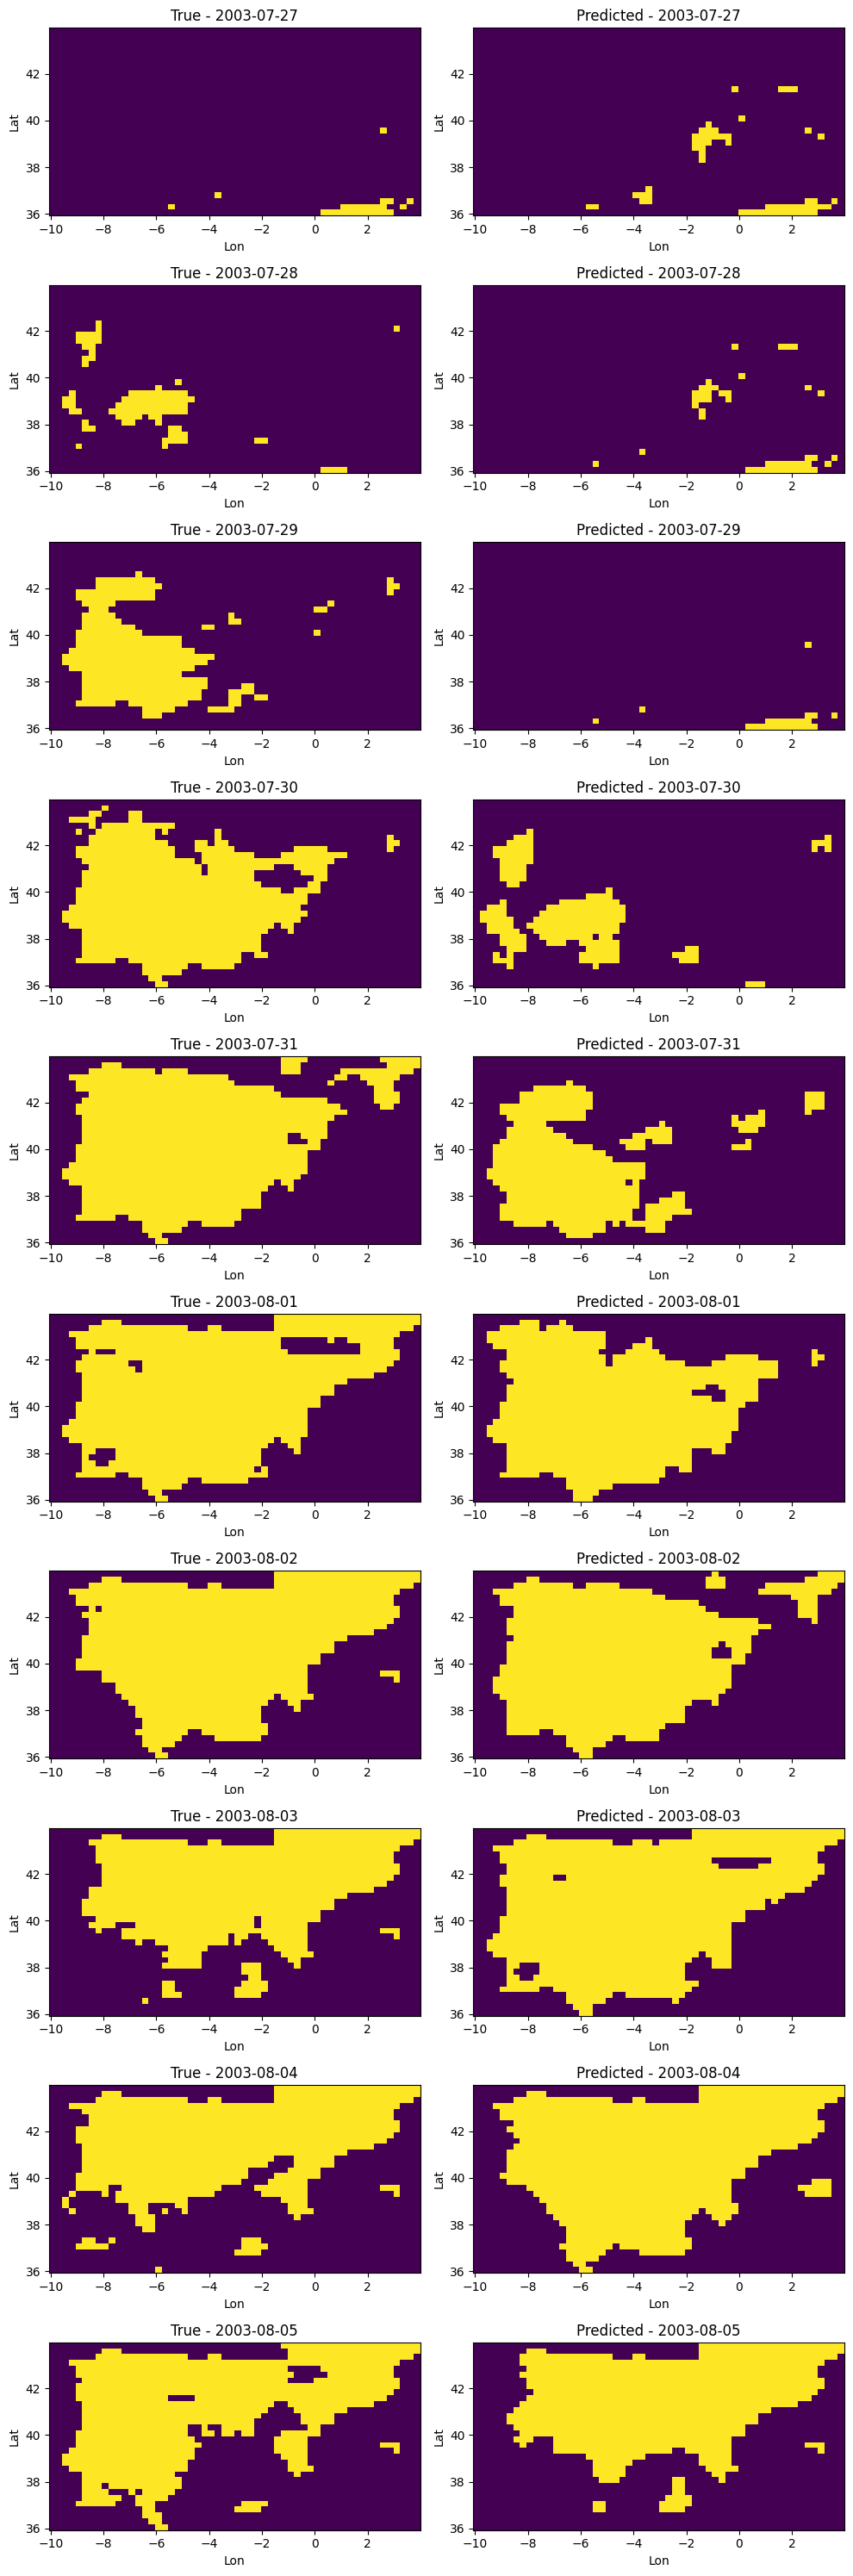

In [160]:
fig, axes = plt.subplots(len(dates_to_plot), 2, figsize=(10, 3 * len(dates_to_plot)))

for i, d in enumerate(dates_to_plot):
    idx = np.where(test_dates == d)[0][0]

    true_map = true[idx, 0]
    pred_map = (pred[idx, 0] >= best_thr).astype(np.uint8)

    im1 = axes[i, 0].pcolormesh(lons, lats, true_map, shading="auto")
    axes[i, 0].set_title(f"True - {str(d)}")
    axes[i, 0].set_xlabel("Lon")
    axes[i, 0].set_ylabel("Lat")

    im2 = axes[i, 1].pcolormesh(lons, lats, pred_map, shading="auto")
    axes[i, 1].set_title(f"Predicted - {str(d)}")
    axes[i, 1].set_xlabel("Lon")
    axes[i, 1].set_ylabel("Lat")

plt.tight_layout()
plt.show()

## Centroid of largest connected component

In [150]:
start_date = np.datetime64("2003-07-27")
end_date   = np.datetime64("2003-08-18")

window_mask = (test_dates >= start_date) & (test_dates <= end_date)

dates_window = test_dates[window_mask]
pred_window = pred[window_mask, 0]
true_window = true[window_mask, 0]

pred_bin_window = (pred_window >= best_thr).astype(np.uint8)
true_bin_window = (true_window >= 0.5).astype(np.uint8)

print(dates_window[0], dates_window[-1], len(dates_window))

2003-07-27 2003-08-18 23


In [ ]:
import numpy as np
from scipy import ndimage

def largest_component_centroid(mask, lats, lons, min_pixels=10):
    """
    mask: (H, W) binary mask
    returns: centroid_lat, centroid_lon, area
    """
    mask = (mask > 0).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)  # 8-connectivity
    labeled, num_features = ndimage.label(mask, structure=structure)

    if num_features == 0:
        return np.nan, np.nan, 0

    best_area = 0
    best_lat = np.nan
    best_lon = np.nan

    for label_id in range(1, num_features + 1):
        rows, cols = np.where(labeled == label_id)
        area = len(rows)

        if area < min_pixels:
            continue

        if area > best_area:
            best_area = area
            best_lat = float(np.mean(lats[rows]))
            best_lon = float(np.mean(lons[cols]))

    if best_area == 0:
        return np.nan, np.nan, 0

    return best_lat, best_lon, best_area

In [152]:
true_lat_traj, true_lon_traj, true_area = [], [], []
pred_lat_traj, pred_lon_traj, pred_area = [], [], []

for t in range(len(dates_window)):
    lat_t, lon_t, area_t = largest_component_centroid(true_bin_window[t], lats, lons, min_pixels=10)
    true_lat_traj.append(lat_t)
    true_lon_traj.append(lon_t)
    true_area.append(area_t)

    lat_p, lon_p, area_p = largest_component_centroid(pred_bin_window[t], lats, lons, min_pixels=10)
    pred_lat_traj.append(lat_p)
    pred_lon_traj.append(lon_p)
    pred_area.append(area_p)

true_lat_traj = np.array(true_lat_traj)
true_lon_traj = np.array(true_lon_traj)
true_area = np.array(true_area)

pred_lat_traj = np.array(pred_lat_traj)
pred_lon_traj = np.array(pred_lon_traj)
pred_area = np.array(pred_area)

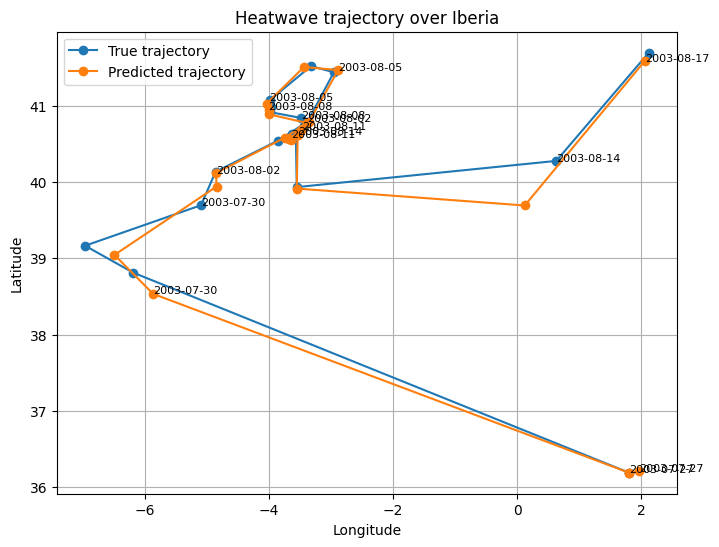

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(true_lon_traj, true_lat_traj, marker="o", label="True trajectory")
plt.plot(pred_lon_traj, pred_lat_traj, marker="o", label="Predicted trajectory")

for i, d in enumerate(dates_window):
    if i % 3 == 0:
        plt.text(true_lon_traj[i], true_lat_traj[i], str(d)[:10], fontsize=8)
        plt.text(pred_lon_traj[i], pred_lat_traj[i], str(d)[:10], fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Heatwave trajectory over Iberia")
plt.legend()
plt.grid(True)
plt.show()

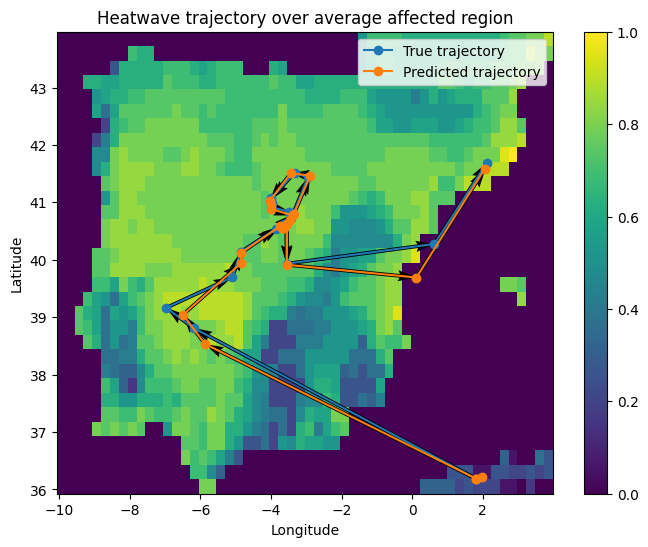

In [163]:
mean_true_mask = true_bin_window.mean(axis=0)

plt.figure(figsize=(8, 6))
plt.pcolormesh(lons, lats, mean_true_mask, shading="auto")

# plot trajectories
plt.plot(true_lon_traj, true_lat_traj, marker="o", label="True trajectory")
plt.plot(pred_lon_traj, pred_lat_traj, marker="o", label="Predicted trajectory")

# arrows for TRUE trajectory
plt.quiver(
    true_lon_traj[:-1], true_lat_traj[:-1],
    np.diff(true_lon_traj), np.diff(true_lat_traj),
    angles='xy', scale_units='xy', scale=1
)

# arrows for PRED trajectory
plt.quiver(
    pred_lon_traj[:-1], pred_lat_traj[:-1],
    np.diff(pred_lon_traj), np.diff(pred_lat_traj),
    angles='xy', scale_units='xy', scale=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Heatwave trajectory over average affected region")
# plt.axis("equal") # 1 degree lat ~ 1 degree lon in this region, so equal aspect ratio 

plt.legend()
plt.colorbar()
plt.show()

#### how often each pixel was labeled as is_heatwave during the time window, for instance pixels with value 1.0 were affected by the heatwave for the whole time window

### Did the predicted trajectory move through the actual heatwave region?

In [179]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from datetime import datetime, timedelta

start_date = datetime(2003, 7, 27)
T = true_bin_window.shape[0]
dates = [start_date + timedelta(days=i) for i in range(T)]

# align predictions to true dates
pred_lon_aligned = np.full(T, np.nan)
pred_lat_aligned = np.full(T, np.nan)
pred_lon_aligned[1:] = pred_lon_traj[:-1]
pred_lat_aligned[1:] = pred_lat_traj[:-1]

frame_dir = "gif_frames"
os.makedirs(frame_dir, exist_ok=True)
frame_paths = []

for t in range(T):
    fig, ax = plt.subplots(figsize=(8, 6))

    pcm = ax.pcolormesh(lons, lats, true_bin_window[t], shading="auto")

    # true trajectory so far
    ax.plot(
        true_lon_traj[:t+1],
        true_lat_traj[:t+1],
        marker="o",
        label="True trajectory"
    )

    # predicted trajectory so far (aligned)
    ax.plot(
        pred_lon_aligned[:t+1],
        pred_lat_aligned[:t+1],
        marker="o",
        label="Predicted trajectory"
    )

    # true arrow
    if t > 0:
        if not np.any(np.isnan([
            true_lon_traj[t-1], true_lat_traj[t-1],
            true_lon_traj[t], true_lat_traj[t]
        ])):
            ax.arrow(
                true_lon_traj[t-1], true_lat_traj[t-1],
                true_lon_traj[t] - true_lon_traj[t-1],
                true_lat_traj[t] - true_lat_traj[t-1],
                length_includes_head=True,
                head_width=0.3,
                head_length=0.3
            )

    # predicted arrow
    if t > 1:
        if not np.any(np.isnan([
            pred_lon_aligned[t-1], pred_lat_aligned[t-1],
            pred_lon_aligned[t], pred_lat_aligned[t]
        ])):
            ax.arrow(
                pred_lon_aligned[t-1], pred_lat_aligned[t-1],
                pred_lon_aligned[t] - pred_lon_aligned[t-1],
                pred_lat_aligned[t] - pred_lat_aligned[t-1],
                length_includes_head=True,
                head_width=0.3,
                head_length=0.3
            )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Heatwave propagation - {dates[t].strftime('%d.%m.%Y')}")
    ax.legend(loc="upper right")
    fig.colorbar(pcm, ax=ax, label="True heatwave mask")
    ax.set_aspect("equal")

    frame_path = os.path.join(frame_dir, f"frame_{t:02d}.png")
    plt.savefig(frame_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(frame_path)

gif_path = "heatwave_daily_true_vs_pred.gif"
with imageio.get_writer(gif_path, mode="I", fps=1) as writer:
    for frame_path in frame_paths:
        writer.append_data(imageio.imread(frame_path))

print(f"Saved GIF to: {gif_path}")

Saved GIF to: heatwave_daily_true_vs_pred.gif


In [156]:
centroid_error = np.sqrt((true_lat_traj - pred_lat_traj)**2 + (true_lon_traj - pred_lon_traj)**2)

print("Mean centroid error (degrees):", np.nanmean(centroid_error))
print("Median centroid error (degrees):", np.nanmedian(centroid_error))

Mean centroid error (degrees): 2.020435005650004
Median centroid error (degrees): 0.9551618337689753


## Predict Clustering Coefficient (CC) instead of is_heatwave

In [213]:
def normalize_target(y_train, y_val, y_test, eps=1e-6):
    mean = y_train.mean()
    std  = y_train.std()
    return ((y_train - mean) / (std + eps),
            (y_val   - mean) / (std + eps),
            (y_test  - mean) / (std + eps),
            mean, std)

y_train_n, y_val_n, y_test_n, y_mean, y_std = normalize_target(y_train, y_val, y_test)

In [216]:
class ConvLSTM(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.head = nn.Conv2d(hidden_dim, 1, kernel_size=1)

    def forward(self, x):
        B, L, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)

        for t in range(L):
            h, c = self.cell(x[:, t], h, c)

        out = self.head(h)
        out = torch.sigmoid(out)   # important for CC in [0,1]
        return out

In [217]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = NumpySeqDataset(X_train_n, y_train)
val_ds   = NumpySeqDataset(X_val_n, y_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

input_dim = X_train_n.shape[2]   # number of channels in input
model = ConvLSTM(input_dim=input_dim, hidden_dim=32, kernel_size=3).to(device)

criterion = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 11):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        opt.step()

    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f}")

Epoch 01 | val_loss=0.0649
Epoch 02 | val_loss=0.0572
Epoch 03 | val_loss=0.0559
Epoch 04 | val_loss=0.0552
Epoch 05 | val_loss=0.0543
Epoch 06 | val_loss=0.0544
Epoch 07 | val_loss=0.0547
Epoch 08 | val_loss=0.0546
Epoch 09 | val_loss=0.0541
Epoch 10 | val_loss=0.0540


In [218]:
from torch.utils.data import DataLoader
import numpy as np

test_ds = NumpySeqDataset(X_test_n, y_test_n)   # <-- NOTE: y_test_n, not y_test
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model.eval()
all_pred = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred_n = model(Xb).cpu().numpy()   # <-- raw output, no sigmoid
        all_pred.append(pred_n)
        all_true.append(yb.numpy())

pred_n = np.concatenate(all_pred, axis=0)   # (N, 1, H, W) normalized predictions
true_n = np.concatenate(all_true, axis=0)   # (N, 1, H, W) normalized ground truth

# Unnormalize back to CC scale
pred = pred_n * y_std + y_mean
true = true_n * y_std + y_mean

# Regression metrics
mse  = np.mean((pred - true)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(pred - true))

print("Test RMSE (CC):", float(rmse))
print("Test MAE  (CC):", float(mae))

Test RMSE (CC): 0.37751051783561707
Test MAE  (CC): 0.2631480097770691


## Visualise the predictions of Clustering Coefficient (CC) - (1st of August 2003)

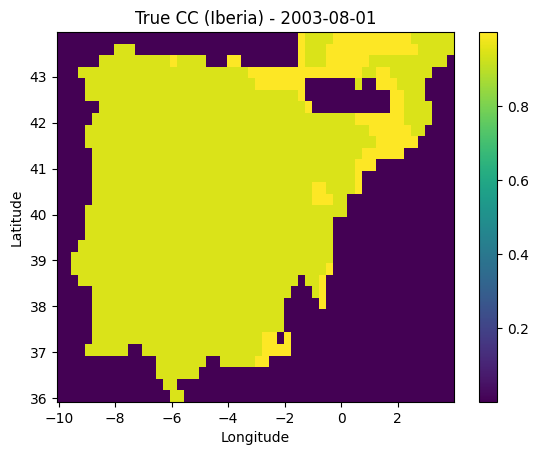

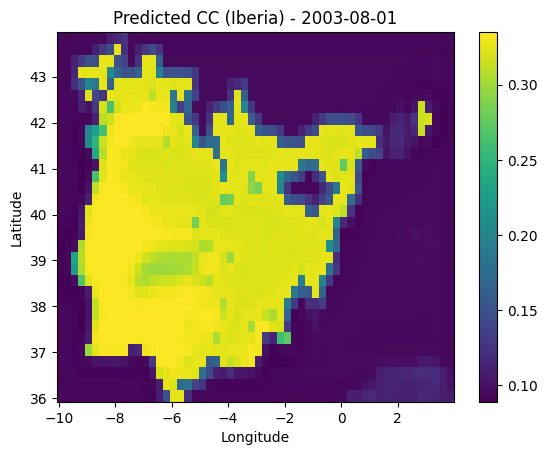

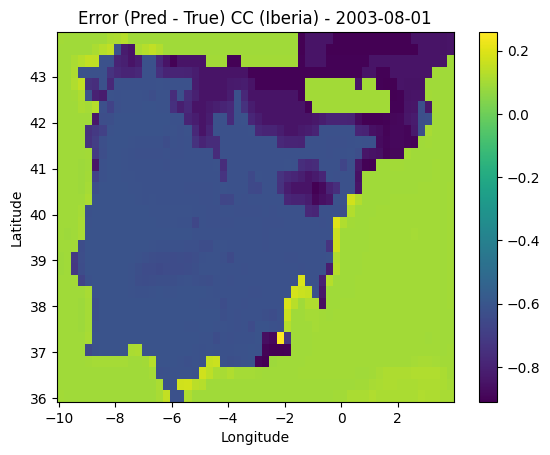

In [219]:
import numpy as np
import matplotlib.pyplot as plt

# pick a target date OR just pick an index
target_date = np.datetime64("2003-08-01")

# find index in test set
idx = int(np.where(test_dates == target_date)[0][0])

pred_map = pred[idx, 0]   # (H,W)
true_map = true[idx, 0]
err_map  = pred_map - true_map

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_cc_lonlat(field, title):
    plt.figure()
    plt.pcolormesh(lons, lats, field, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_cc_lonlat(true_map, f"True CC (Iberia) - {str(target_date)}")
plot_cc_lonlat(pred_map, f"Predicted CC (Iberia) - {str(target_date)}")
plot_cc_lonlat(err_map,  f"Error (Pred - True) CC (Iberia) - {str(target_date)}")

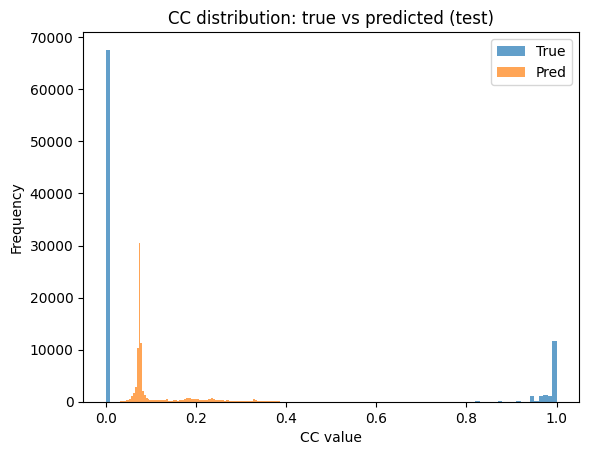

In [87]:
plt.figure()
plt.hist(true.ravel(), bins=100, alpha=0.7, label="True")
plt.hist(pred.ravel(), bins=100, alpha=0.7, label="Pred")
plt.title("CC distribution: true vs predicted (test)")
plt.xlabel("CC value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


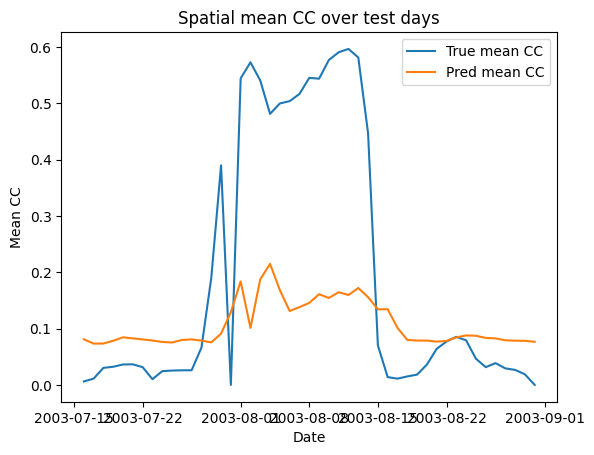

In [88]:
true_mean = true.mean(axis=(2,3)).squeeze()  # (N,)
pred_mean = pred.mean(axis=(2,3)).squeeze()

plt.figure()
plt.plot(test_dates, true_mean, label="True mean CC")
plt.plot(test_dates, pred_mean, label="Pred mean CC")
plt.title("Spatial mean CC over test days")
plt.xlabel("Date")
plt.ylabel("Mean CC")
plt.legend()
plt.show()

## Can the model learn network structure evolution?

Degree Centrality (DC)

How synchronized a region is with others.

➡ high = many regions experiencing heat together
➡ hubs of heatwave activity

Clustering Coefficient (CC)

Local clustering of heatwaves.

➡ high = localized heatwave cluster
➡ stationary behaviour

Betweenness Centrality (BC)

Propagation corridor importance.

➡ high = heatwave movement pathway
➡ dynamic propagation routes

Use CN metrics to:

✔ identify propagation corridors
✔ detect dynamic heatwaves
✔ validate DL trajectories

Use is_heatwave to:

✔ define events
✔ train models
✔ detect movement

Use E-OBS Tmax to:

✔ build sequences
✔ provide physical context